# 01 — Data Pipeline
**BTL IS54A — Nhóm 3 | Người 1**

Notebook này demo toàn bộ pipeline xử lý dữ liệu:
1. Mount Google Drive
2. Cài thư viện
3. Chạy `split_student.py` → tạo 3 CSV
4. Test `build_affectnet_dataset()` — Phase 1
5. Test `build_student_dataset()` — Phase 2
6. Visualize augmentation
7. In class_weights của AffectNet

---
**Cách dùng lại ở notebook khác (Người 2–5):**
```python
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')

!pip install mtcnn -q
from preprocess import init_mtcnn
init_mtcnn()  # khởi tạo MTCNN 1 lần

from dataset_affectnet import build_affectnet_dataset
from dataset_student import build_student_dataset

# ── Đường dẫn (THAY NẾU CẦN) ──────────────────────────────────────
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
STUDENT_DIR   = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'
# AFFECTNET_DIR : ảnh gốc AffectNet → dùng cho build_affectnet_dataset()
# STUDENT_DIR   : ảnh gốc Student   → chỉ cần nếu chạy lại split_student.py
# DATA_DIR      : chứa 3 file CSV   → dùng cho build_student_dataset()
```

## 1. Setup — Mount Drive & Cài thư viện

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted OK')

Mounted at /content/drive
Drive mounted OK


In [2]:
!pip install mtcnn -q
print('mtcnn installed OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.0 MB/s eta 0:00:00
mtcnn installed OK


In [3]:
import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')

# Đường dẫn cấu hình — THAY NẾU CẦN
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
STUDENT_DIR   = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'

print('Paths configured')

Paths configured


## 2. Tạo CSV Split cho Student Dataset

In [4]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, f'{DATA_DIR}/split_student.py',
     '--student_dir', STUDENT_DIR,
     '--out_dir', DATA_DIR],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Tổng số ảnh thu thập: 2120
label
Looking Away    423
Confused        369
Frustrated      360
Bored           358
Focused         347
Drowsy          263

Split hoàn tất:
  Train :  1484 ảnh  → /content/drive/MyDrive/ProjectBTL/BTL/data/student_train.csv
  Val   :   318 ảnh  → /content/drive/MyDrive/ProjectBTL/BTL/data/student_val.csv
  Test  :   318 ảnh  → /content/drive/MyDrive/ProjectBTL/BTL/data/student_test.csv

Phân bố Drowsy qua các split:
  Train: 184 ảnh
  Val: 39 ảnh
  Test: 40 ảnh



In [ ]:
import pandas as pd
from pathlib import Path

for split in ['train', 'val', 'test']:
    df = pd.read_csv(f'{DATA_DIR}/student_{split}.csv')
    print(f'\n--- {split} ({len(df)} ảnh) ---')
    print(df['label'].value_counts().to_string())

## 3. Test AffectNet Dataset (Phase 1)

In [8]:
from dataset_affectnet import build_affectnet_dataset

# subset_per_class=5 để test nhanh
train_ds, class_weights = build_affectnet_dataset(
    split='train',
    data_dir=AFFECTNET_DIR,
    batch_size=8,
    subset_per_class=5
)

# Lấy 1 batch kiểm tra shape
for images, labels in train_ds.take(1):
    print(f'Image batch shape : {images.shape}')   # (8, 224, 224, 3)
    print(f'Label batch shape : {labels.shape}')   # (8, 8)
    print(f'Image min/max     : {images.numpy().min():.3f} / {images.numpy().max():.3f}')

print(f'\nclass_weights (8 keys): {class_weights}')

[dataset_affectnet] train: 40 ảnh
Image batch shape : (8, 224, 224, 3)
Label batch shape : (8, 8)
Image min/max     : -2.716 / 3.095

class_weights (8 keys): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0}


## 4. Test Student Dataset (Phase 2)

In [4]:
# Khởi tạo MTCNN 1 lần
from preprocess import init_mtcnn
init_mtcnn()

[preprocess] MTCNN khởi tạo thành công.


In [5]:
from dataset_student import build_student_dataset

train_student_ds = build_student_dataset(
    split='train', data_dir=DATA_DIR, batch_size=8
)

for images, labels in train_student_ds.take(1):
    print(f'Image batch shape : {images.shape}')   # (8, 224, 224, 3)
    print(f'Label batch shape : {labels.shape}')   # (8, 6)
    print(f'Image min/max     : {images.numpy().min():.3f} / {images.numpy().max():.3f}')

[dataset_student] train: 1484 ảnh
label
Looking Away    296
Confused        258
Frustrated      252
Bored           251
Focused         243
Drowsy          184
[preprocess] MTCNN error: Exception encountered when calling Conv2D.call().

The convolution operation resulted in an empty output. Output shape: (0, 46, 46, 32). This can happen if the input is too small for the given kernel size, strides, dilation rate, and padding mode. Please check the input shape and convolution parameters.

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(0, 48, 48, 3), dtype=float32)
Image batch shape : (8, 224, 224, 3)
Label batch shape : (8, 6)
Image min/max     : -2.313 / 3.299


## 5. Visualize Augmentation

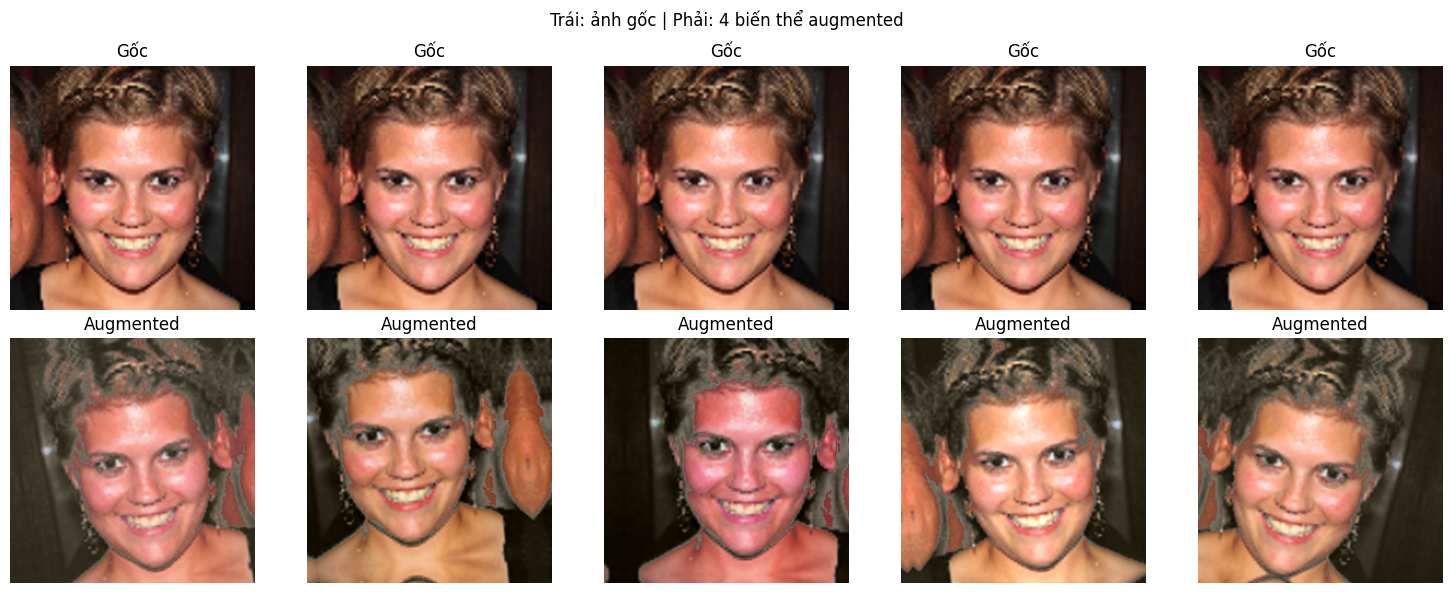

Lưu ảnh: augmentation_sample.png


In [6]:
import matplotlib.pyplot as plt
import tensorflow as tf
from preprocess import resize_affectnet
from augmentation import augment_train
import glob, os

# Lấy 1 ảnh AffectNet mẫu
sample_imgs = glob.glob(os.path.join(AFFECTNET_DIR, 'Train', 'happy', '*.png'))[:1]
if sample_imgs:
    orig = resize_affectnet(sample_imgs[0])

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Trái: ảnh gốc | Phải: 4 biến thể augmented', fontsize=12)

    # Hàng 1: ảnh gốc (lặp lại 5 lần để so sánh)
    for ax in axes[0]:
        # Denormalize để hiển thị
        img_show = orig.numpy() * [0.229,0.224,0.225] + [0.485,0.456,0.406]
        ax.imshow(img_show.clip(0,1))
        ax.set_title('Gốc')
        ax.axis('off')

    # Hàng 2: augmented
    for ax in axes[1]:
        aug = augment_train(orig).numpy()
        img_show = aug * [0.229,0.224,0.225] + [0.485,0.456,0.406]
        ax.imshow(img_show.clip(0,1))
        ax.set_title('Augmented')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}/../augmentation_sample.png', dpi=100)
    plt.show()
    print('Lưu ảnh: augmentation_sample.png')
else:
    print('Không tìm thấy ảnh mẫu AffectNet')

## 6. Tóm tắt Class Weights AffectNet

In [9]:
from dataset_affectnet import LABEL_MAP

idx_to_name = {v: k for k, v in LABEL_MAP.items()}

print('Class Weights AffectNet:')
print(f'{"Class":<12} {"Index":>5}  {"Weight":>8}')
print('-' * 30)
for idx, w in sorted(class_weights.items()):
    print(f'{idx_to_name[idx]:<12} {idx:>5}  {w:>8.4f}')

Class Weights AffectNet:
Class        Index    Weight
------------------------------
anger            0    1.0000
contempt         1    1.0000
disgust          2    1.0000
fear             3    1.0000
happy            4    1.0000
neutral          5    1.0000
sad              6    1.0000
surprise         7    1.0000


---
## ✅ Pipeline sẵn sàng

Người 2–5 copy đoạn code sau vào đầu notebook của mình:

```python
# ══ PASTE VÀO ĐẦU MỖI NOTEBOOK ══════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/ProjectBTL/BTL/data')

!pip install mtcnn -q
from preprocess import init_mtcnn
init_mtcnn()  # khởi tạo MTCNN 1 lần (cần cho Student Dataset)

from dataset_affectnet import build_affectnet_dataset
from dataset_student import build_student_dataset

# ── Đường dẫn ────────────────────────────────────────────────────────
AFFECTNET_DIR = '/content/drive/MyDrive/ProjectBTL/AffectNet'
STUDENT_DIR   = '/content/drive/MyDrive/ProjectBTL/Student Dataset/Student-engagement-dataset'
DATA_DIR      = '/content/drive/MyDrive/ProjectBTL/BTL/data'
# AFFECTNET_DIR : ảnh gốc AffectNet  → dùng cho build_affectnet_dataset()
# STUDENT_DIR   : ảnh gốc Student    → chỉ cần nếu chạy lại split_student.py
# DATA_DIR      : chứa 3 file CSV    → dùng cho build_student_dataset()

# ══ SAU ĐÓ DÙNG BÌNH THƯỜNG ═════════════════════════════════════════

# Phase 1 — train trên AffectNet (8 cảm xúc)
train_ds, class_weights = build_affectnet_dataset(
    'train', AFFECTNET_DIR, batch_size=32, subset_per_class=1500
)
test_ds, _ = build_affectnet_dataset('test', AFFECTNET_DIR, batch_size=32)

# Phase 2 — fine-tune trên Student Dataset (6 trạng thái)
train_student = build_student_dataset('train', DATA_DIR, batch_size=16)
val_student   = build_student_dataset('val',   DATA_DIR, batch_size=16)
test_student  = build_student_dataset('test',  DATA_DIR, batch_size=16)

# Train:
model.fit(train_ds, class_weight=class_weights, epochs=20, ...)       # Phase 1
model.fit(train_student, validation_data=val_student, epochs=15, ...) # Phase 2
```

---
### Giải thích 3 đường dẫn

| Biến | Trỏ đến | Ai dùng |
|------|---------|---------|
| `AFFECTNET_DIR` | Thư mục ảnh gốc AffectNet (Train/ + Test/) | Tất cả (Phase 1) |
| `STUDENT_DIR` | Thư mục ảnh gốc Student Dataset | Chỉ khi chạy lại `split_student.py` |
| `DATA_DIR` | Thư mục chứa 3 CSV split | Tất cả (Phase 2) |

> ⚠️ **Lưu ý:** `build_student_dataset()` đọc từ **CSV trong `DATA_DIR`**, không đọc trực tiếp từ `STUDENT_DIR`.
> CSV đã được Người 1 tạo sẵn với đường dẫn Colab — **không cần chạy lại** `split_student.py`.